In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from lmfit import Model

In [5]:
def field_model(z, Br, R, L, z0):
    Z_eff = z + z0 
    term1 = (Z_eff + L) / np.sqrt(R**2 + (Z_eff + L)**2)
    term2 = Z_eff / np.sqrt(R**2 + Z_eff**2)
    return (Br / 2) * (term1 - term2)

def field_deriv(z, Br, R, L, z0):
    Z = z + z0
    deriv_term1 = R**2 / (R**2 + (Z + L)**2)**(1.5)
    deriv_term2 = R**2 / (R**2 + Z**2)**(1.5)
    db_dz = (Br / 2) * (deriv_term1 - deriv_term2) 
    return db_dz

In [12]:
def plot_and_fit(df, label = '', units = 'mks', R=14.075, L=7.25): #R,L en mm
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=150)

    if units == 'mks':
        d = df['d [mm]'][:]
        B = df['B [mT]'][:]
        d_err = df['delta_d [mm]'][:]
        B_err = df['delta_B [mT]'][:]
        ax.set_xlabel(r'Distance [$mm$]', fontweight='bold')
        ax.set_ylabel(r'Magnetic Field [$mT$]', fontweight='bold')
        
    elif units == 'cgs':
        d = df['d [cm]']*10
        B = df['B [G]'][:]
        d_err = df['delta_d [cm]']*10
        B_err = df['delta_B [G]'][:]
        ax.set_xlabel(r'Distance [$mm$]', fontweight='bold')
        ax.set_ylabel(r'Magnetic Field [$G$]', fontweight='bold')

    ax.errorbar(d, B, xerr = d_err, yerr=B_err, fmt='ks', markersize=3, capsize=2, 
                elinewidth=0.4, markeredgecolor='black', markerfacecolor='white', 
                label='Experimental Data', zorder=3)
    
    magnet_model = Model(field_model)

    params = magnet_model.make_params()
 
    params['R'].set(value=R, vary=False)
    params['L'].set(value=L, vary=False)
    params['Br'].set(value=12500, min=10500, max=15000)
    params['z0'].set(value=0.05, min=-5.0, max=5.0)
    
    result = magnet_model.fit(B, params, z=d, method='dual_annealing')

    Br_fit = result.params['Br'].value
    Br_error = result.params['Br'].stderr
    
    z0_fit = result.params['z0'].value
    z0_error = result.params['z0'].stderr

    t = np.linspace(min(d), max(d), 1000)
    B_fit = field_model(t, Br = Br_fit, R=R, L=L, z0 = z0_fit)
    ax.plot(t, B_fit, linewidth = 0.6,color="blue", label = 'Fit', zorder =2)
    ax.set_title('Figure 1. NdFeB Magnet Characterization Curve', pad=10)

    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', frameon=True)
    
    plt.tight_layout()
    plt.savefig('graphs/magnet_' + label +'_characteristic_curve.png', bbox_inches='tight')
    plt.show()

    fig, bx = plt.subplots(figsize=(4, 3), dpi=150)
    
    window = 11
    poly = 3

    dd = d[1] - d[0]
    dB_dd_numerical = savgol_filter(B, window_length=window, polyorder=poly, deriv=1, delta=dd)

    bx.errorbar(d, dB_dd_numerical, fmt='ks', markersize=3, capsize=2, 
                elinewidth=0.4, markeredgecolor='black', markerfacecolor='white', 
                label='Experimental Data', zorder=3)

    dB_dd_analytical = field_deriv(t, Br=Br_fit, R=R, L=L, z0=z0_fit)
    ax.plot(t,dB_dd_analytical, linewidth = 0.6,color="blue", label = 'Fit', zorder =2)

    if units == 'mks':
        bx.set_xlabel(r'Distance [$mm$]', fontweight='bold')
        bx.set_ylabel(r' [$T/m$]', fontweight='bold')
        
    elif units == 'cgs':
        bx.set_xlabel(r'Distance [$mm$]', fontweight='bold')
        bx.set_ylabel(r' [$G/mm$]', fontweight='bold')
        
    bx.set_title('Figure 2. NdFeB Magnet Numerical Derivatve', pad=10)

    bx.grid(True, which='both', linestyle='--', alpha=0.5)
    bx.legend(loc='lower right', frameon=True)
    
    plt.tight_layout()
    plt.savefig('graphs/magnet_' + label + '_numerical_derivative.png', bbox_inches='tight')
    plt.show()

    print(result.fit_report())

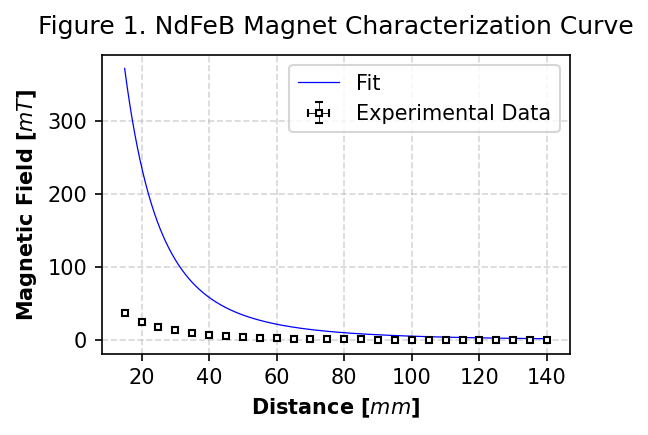

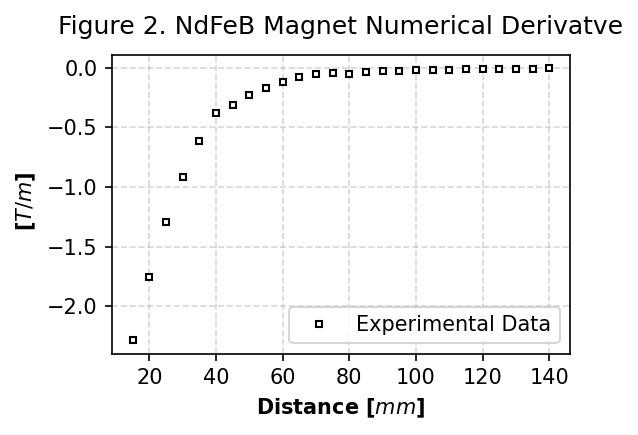

[[Model]]
    Model(field_model)
[[Fit Statistics]]
    # fitting method   = dual_annealing
    # function evals   = 4016
    # data points      = 26
    # variables        = 2
    chi-square         = 196395.592
    reduced chi-square = 8183.14966
    Akaike info crit   = 236.174532
    Bayesian info crit = 238.690725
    R-squared          = -95.9368598
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    Br:  10500.0000 (init = 12500)
    R:   14.075 (fixed)
    L:   7.25 (fixed)
    z0:  5.00000000 (init = 0.05)


In [13]:
df = pd.read_csv('data/nb_magnet_data_11_02_2026_1.csv')
plot_and_fit(df, '11_02_2026_1', units = 'mks')

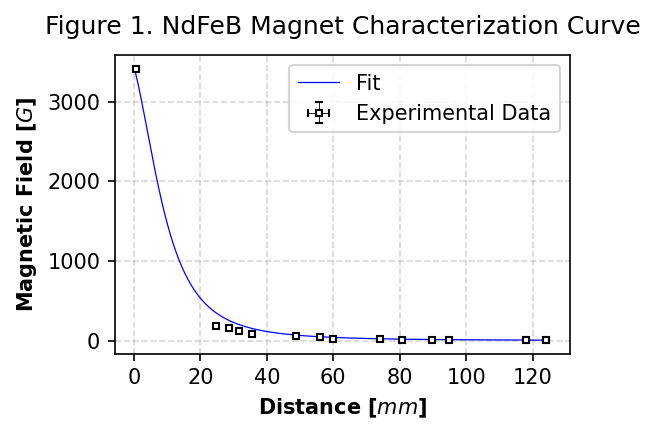

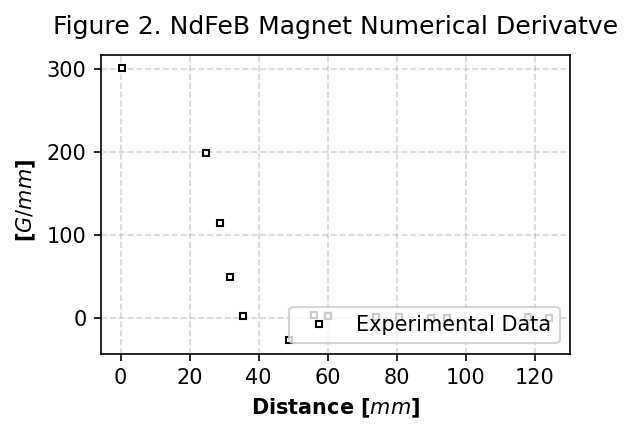

[[Model]]
    Model(field_model)
[[Fit Statistics]]
    # fitting method   = dual_annealing
    # function evals   = 4052
    # data points      = 14
    # variables        = 2
    chi-square         = 50404.4031
    reduced chi-square = 4200.36693
    Akaike info crit   = 118.642871
    Bayesian info crit = 119.920985
    R-squared          = 0.99519617
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    Br:  15000.0000 (init = 12500)
    R:   14.075 (fixed)
    L:   7.25 (fixed)
    z0: -0.05943348 (init = 0.05)


In [14]:
df1 = pd.read_csv('data/nb_magnet_data_16_02_2026_1.csv')
plot_and_fit(df1, '16_02_2026_1', units = 'cgs')

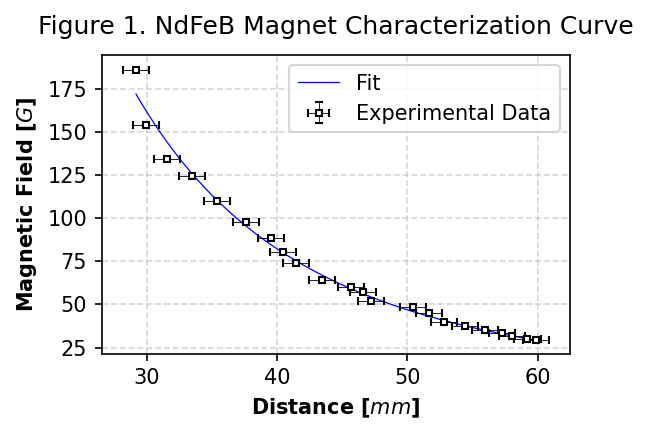

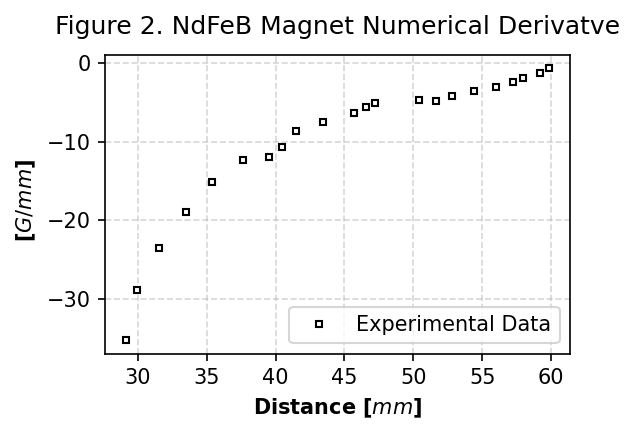

[[Model]]
    Model(field_model)
[[Fit Statistics]]
    # fitting method   = dual_annealing
    # function evals   = 4145
    # data points      = 22
    # variables        = 2
    chi-square         = 403.269596
    reduced chi-square = 20.1634798
    Akaike info crit   = 67.9883829
    Bayesian info crit = 70.1704678
    R-squared          = 0.99021112
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    Br:  11751.7015 (init = 12500)
    R:   14.075 (fixed)
    L:   7.25 (fixed)
    z0:  1.20038213 (init = 0.05)


In [15]:
df2 = pd.read_csv('data/nb_magnet_data_16_02_2026_2.csv')
df2 = df2.iloc[:, :4]
plot_and_fit(df2, '16_02_2026_2', units = 'cgs')

In [1]:
def plot_force(df, label = '', R=1.4075, L=0.725): #R,L en cm
    fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
    
    F = df['m [g]']*9.81*1E-3
    d = df['d [cm]']*10
    F_err = df['delta_m [g]']*9.81*1E-3
    d_err = df['delta_d [cm]']*10
    ax.set_xlabel(r'Distance [$mm$]', fontweight='bold')
    ax.set_ylabel(r'Force [$N$]', fontweight='bold')

    ax.errorbar(d, B, xerr = d_err, yerr=B_err, fmt='ks', markersize=3, capsize=2, 
                elinewidth=0.4, markeredgecolor='black', markerfacecolor='white', 
                label='Experimental Data', zorder=3)